In [63]:
import os
import logging
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

logging.getLogger("tensorflow").setLevel(logging.ERROR)

from transformers import AutoTokenizer, TFAutoModel
from arabert.preprocess import ArabertPreprocessor
from sklearn.metrics import confusion_matrix, classification_report

# symbolic model imports
from symbolicModel import (
    build_symbolic_matrix,
    learn_rule_confidence,
    RULE_CONFIDENCE,
    symbolic_detector,
    show_symbolic_result
)

# Config
ModelName  = "aubmindlab/bert-large-arabertv02"
DATA_DIR   = "/Users/roamsaleh/Downloads/similedata/"

# MAX_LEN reduced from 120 → 32 after analyzing token-length distribution.
# Most sentences in the dataset are under 30 tokens, so longer padding
# provides no performance benefit and only increases memory usage.
# Transformer memory/computation scales approximately as O(n²)
MAX_LEN    = 32
BATCH_SIZE = 32
SEED       = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [64]:
# LOAD DATA
train_df = pd.read_csv(DATA_DIR + "cleaned_train.csv")
val_df   = pd.read_csv(DATA_DIR + "cleaned_validation.csv")
test_df  = pd.read_csv(DATA_DIR + "cleaned_test.csv")

X_train = train_df["text"].tolist()
y_train = train_df["label"].tolist()

X_val = val_df["text"].tolist()
y_val = val_df["label"].tolist()

X_test = test_df["text"].tolist()
y_test = test_df["label"].tolist()

print(len(X_train), len(X_val), len(X_test))

6000 1108 3000


(array([  2.,  58., 234., 376., 485., 504., 532., 567., 497., 528., 435.,
        370., 333., 301., 259., 159., 102.,  91.,  57.,  42.,  31.,  19.,
          3.,   5.,   4.,   1.,   2.,   0.,   2.,   1.]),
 array([ 1.        ,  1.96666667,  2.93333333,  3.9       ,  4.86666667,
         5.83333333,  6.8       ,  7.76666667,  8.73333333,  9.7       ,
        10.66666667, 11.63333333, 12.6       , 13.56666667, 14.53333333,
        15.5       , 16.46666667, 17.43333333, 18.4       , 19.36666667,
        20.33333333, 21.3       , 22.26666667, 23.23333333, 24.2       ,
        25.16666667, 26.13333333, 27.1       , 28.06666667, 29.03333333,
        30.        ]),
 <BarContainer object of 30 artists>)

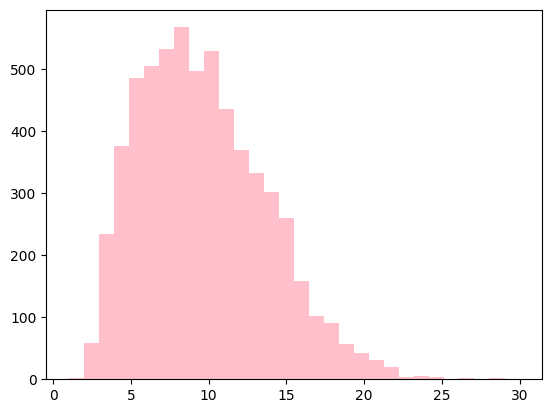

In [65]:
lengths = [len(tokenizer.tokenize(x)) for x in X_train]
plt.hist(lengths, bins=30, color='pink')

In [66]:
lengths = [len(tokenizer.tokenize(x)) for x in X_train]

print("Max:", max(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("99th percentile:", np.percentile(lengths, 99))

Max: 30
95th percentile: 17.0
99th percentile: 21.0


data-driven symbolic confidence estimation

In [67]:
# symbolic rule confidence dapting them from data
learned_scores = learn_rule_confidence(X_train, y_train)
RULE_CONFIDENCE.update(learned_scores)
print("\nLearned Rule Confidence:")
print(RULE_CONFIDENCE)

# Build symbolic feature matrices for all datasets
X_train_sym = build_symbolic_matrix(X_train)
X_val_sym   = build_symbolic_matrix(X_val)
X_test_sym  = build_symbolic_matrix(X_test)

# Check shapes to confirm symbolic features are generated correctly
print("\nSymbolic Feature Shapes:")
print(X_train_sym.shape, X_val_sym.shape, X_test_sym.shape)


Learned Rule Confidence:
{'explicit_particle': 0.9, 'weak_particle': 0.983, 'verb_simile': 0.927, 'nominal_simile': 0.985, 'prefix_simile': 0.676}

Symbolic Feature Shapes:
(6000, 11) (1108, 11) (3000, 11)


## Symbolic-Only Baseline (Rule-Based Evaluation)

Before evaluating the full hybrid model, the symbolic component was tested independently to measure how well handcrafted linguistic rules can detect Arabic similes on their own.

This baseline uses the symbolic detector directly. For each sentence, the symbolic module identifies simile structures and computes a final confidence score using probabilistic evidence fusion. A sentence is classified as a simile if the symbolic confidence exceeds a predefined threshold (0.5).

This experiment helps answer the following question:

**How much predictive power comes purely from explicit linguistic knowledge, without any neural modeling?**

The symbolic baseline serves as an important reference point for evaluating whether the hybrid model provides meaningful improvement beyond rule-based detection.

In [68]:
'''

SYMBOLIC-ONLY EVALUATION
 Uses only the symbolic detector confidence
 to classify whether a sentence contains a simile.
 Threshold = 0.5 means that if the symbolic confidence is 0.5 or higher, we predict "simile" (1), otherwise "not simile" (0).

'''
def evaluate_symbolic_model(texts, labels, threshold=0.5):

    y_pred = []
    y_prob = []

    for sentence in texts:

        # Run symbolic detector
        result = symbolic_detector(sentence)

        # Final symbolic confidence
        prob = result.confidence
        y_prob.append(prob)

        # Convert probability to class
        pred = 1 if prob >= threshold else 0
        y_pred.append(pred)

    print("\nSymbolic Model Confusion Matrix:")
    print(confusion_matrix(labels, y_pred))

    print("\nSymbolic Model Classification Report:")
    print(classification_report(labels, y_pred))

    return y_pred, y_prob
symbolic_pred, symbolic_prob = evaluate_symbolic_model(
    X_test,
    y_test
)


Symbolic Model Confusion Matrix:
[[1145  333]
 [ 389 1133]]

Symbolic Model Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.77      0.76      1478
           1       0.77      0.74      0.76      1522

    accuracy                           0.76      3000
   macro avg       0.76      0.76      0.76      3000
weighted avg       0.76      0.76      0.76      3000



## Symbolic Feature Learning Check

To verify whether the handcrafted symbolic features contain additional predictive information, a simple Logistic Regression classifier was trained using only the symbolic feature vectors.

Each sentence was converted into an 11-dimensional symbolic representation, and the classifier learned how to map these features to simile/non-simile labels.

The resulting performance was identical to the direct symbolic baseline. This suggests that the handcrafted symbolic confidence mechanism already captures the most important information contained in the symbolic feature space, making an additional symbolic classifier unnecessary.

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# create simple classifier
clf = LogisticRegression()
# train on symbolic features 
clf.fit(X_train_sym, y_train)

# Predict
y_pred = clf.predict(X_test_sym)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76      1478
           1       0.77      0.74      0.76      1522

    accuracy                           0.76      3000
   macro avg       0.76      0.76      0.76      3000
weighted avg       0.76      0.76      0.76      3000



Arabic normalization is essential.
Without this, performance can drop significantly.

In [70]:
# TEXT PREPROCESSING
arabert_prep = ArabertPreprocessor(model_name=ModelName)
tokenizer    = AutoTokenizer.from_pretrained(ModelName)

def PreprocessTexts(texts):
    texts = [arabert_prep.preprocess(t) for t in texts]

    encodings = tokenizer(
        texts,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

    return encodings['input_ids'], encodings['attention_mask']

X_train_ids, X_train_mask = PreprocessTexts(X_train)
X_val_ids, X_val_mask     = PreprocessTexts(X_val)
X_test_ids, X_test_mask   = PreprocessTexts(X_test)

In [75]:
import os

for f in [
    TRAIN_ATTN_CACHE,
    VAL_ATTN_CACHE,
    TEST_ATTN_CACHE
]:
    if os.path.exists(f):
        os.remove(f)
        print("Deleted:", f)

In [76]:
TRAIN_ATTN_CACHE = DATA_DIR + "train_cls_attn.npy"
VAL_ATTN_CACHE   = DATA_DIR + "val_cls_attn.npy"
TEST_ATTN_CACHE  = DATA_DIR + "test_cls_attn.npy"
 
print("\nLoading AraBERT for attention extraction...")
 # Using AraBERT not only for prediction but to inspect where it looks.
arabert_attention = TFAutoModel.from_pretrained(
    ModelName,
    output_attentions=True,
    from_pt=True
)
 
def extract_attention_patterns(input_ids, attention_mask,
                                batch_size=64, cache_path=None):
    """
    Extract [CLS] attention patterns from AraBERT.
    Averaged across all 24 layers and 16 heads.
    Returns np.array (N, MAX_LEN).
    Saves to cache_path so re-runs load instantly.
    """
    if cache_path and os.path.exists(cache_path):
        print(f"  Loading from cache: {cache_path}")
        return np.load(cache_path)
 
    all_cls_attn = []
    total        = input_ids.shape[0]
 
    for start in range(0, total, batch_size):
        end    = min(start + batch_size, total)
        b_ids  = input_ids[start:end]
        b_mask = attention_mask[start:end]
 
        outputs = arabert_attention(
            input_ids=b_ids,
            attention_mask=b_mask,
            training=False,
            return_dict=True
        )
 
        # (24, batch, heads, seq, seq)
        attn_stack = tf.stack(outputs.attentions, axis=0)
 
        # [CLS] attending to all positions → (24, batch, heads, seq)
        cls_attn = attn_stack[:, :, :, 0, :]
 
        # Average layers + heads → (batch, seq)
        cls_attn_mean = tf.reduce_mean(cls_attn, axis=[0, 2])
        all_cls_attn.append(cls_attn_mean.numpy())
 
        if (start // batch_size) % 10 == 0:
            print(f"  {end}/{total}  ({int(end/total*100)}%)")
 
    result = np.vstack(all_cls_attn)
 
    if cache_path:
        np.save(cache_path, result)
        print(f"  Saved to cache: {cache_path}")
 
    return result
 
 
print("\nExtracting attention from train set (runs once, then cached)...")
train_cls_attn = extract_attention_patterns(
    X_train_ids, X_train_mask,
    batch_size=64, cache_path=TRAIN_ATTN_CACHE
)
 
print("Extracting attention from val set...")
val_cls_attn = extract_attention_patterns(
    X_val_ids, X_val_mask,
    batch_size=64, cache_path=VAL_ATTN_CACHE
)
 
print("Extracting attention from test set...")
test_cls_attn = extract_attention_patterns(
    X_test_ids, X_test_mask,
    batch_size=64, cache_path=TEST_ATTN_CACHE
)
 
# STEP 2 — MINE NEURAL RULES FROM ATTENTION
 
def mine_neural_rules(input_ids, cls_attn, labels,
                       top_k=5, ratio_threshold=2.0):
    """
    Discover which tokens AraBERT attends to MORE
    in Simile sentences vs Not Simile sentences.
    Returns a dict of {token: likelihood_ratio}.
    """
    simile_counts     = defaultdict(float)
    not_simile_counts = defaultdict(float)
 
    for idx, (attn_row, label) in enumerate(zip(cls_attn, labels)):
        top_positions = np.argsort(attn_row)[-top_k:]
        for pos in top_positions:
            token_id  = int(input_ids[idx, pos].numpy())
            token = tokenizer.convert_ids_to_tokens(token_id)
            if token in ['[CLS]', '[SEP]', '[PAD]', '']:
                continue
            if token.startswith("##"):
                continue

            token_str = token

            if label == 1:
                simile_counts[token_str]     += attn_row[pos]
            else:
                not_simile_counts[token_str] += attn_row[pos]
 
    simile_total     = sum(simile_counts.values())     + 1e-8
    not_simile_total = sum(not_simile_counts.values()) + 1e-8
 
    likelihood_ratios = {}

    for token in set(simile_counts) | set(not_simile_counts):
        p_s  = simile_counts.get(token, 1e-8)     / simile_total
        p_ns = not_simile_counts.get(token, 1e-8) / not_simile_total
        likelihood_ratios[token] = p_s / p_ns
 
    discriminative = {
        t: r for t, r in likelihood_ratios.items()
        if r > ratio_threshold
    }
    discriminative = dict(
        sorted(discriminative.items(), key=lambda x: x[1], reverse=True)
    )
 
    print("\nNeural Rules Discovered from Attention:")
    for token, ratio in list(discriminative.items())[:15]:
        print(f"  → '{token}'  (likelihood ratio: {ratio:.2f}x)")
 
    return discriminative
 
 
print("\nMining neural rules from training attention...")
discriminative_tokens = mine_neural_rules(
    X_train_ids, train_cls_attn, y_train
)


Loading AraBERT for attention extraction...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'bert.embeddings.position_ids', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the 


Extracting attention from train set (runs once, then cached)...
  64/6000  (1%)
  704/6000  (11%)
  1344/6000  (22%)
  1984/6000  (33%)
  2624/6000  (43%)
  3264/6000  (54%)
  3904/6000  (65%)
  4544/6000  (75%)
  5184/6000  (86%)
  5824/6000  (97%)
  Saved to cache: /Users/roamsaleh/Downloads/similedata/train_cls_attn.npy
Extracting attention from val set...
  64/1108  (5%)
  704/1108  (63%)
  Saved to cache: /Users/roamsaleh/Downloads/similedata/val_cls_attn.npy
Extracting attention from test set...
  64/3000  (2%)
  704/3000  (23%)
  1344/3000  (44%)
  1984/3000  (66%)
  2624/3000  (87%)
  Saved to cache: /Users/roamsaleh/Downloads/similedata/test_cls_attn.npy

Mining neural rules from training attention...

Neural Rules Discovered from Attention:
  → 'اشبه'  (likelihood ratio: 45811804.00x)
  → 'حقيقي'  (likelihood ratio: 44421856.00x)
  → 'كالم'  (likelihood ratio: 42186352.00x)
  → 'يشبه'  (likelihood ratio: 38359440.00x)
  → 'كال'  (likelihood ratio: 37617036.00x)
  → 'الطوب'  

## Neural Attention Feature Engineering

In this stage, raw attention maps from AraBERT are transformed into compact, interpretable numerical features. Instead of using full attention matrices, the goal is to compress the model’s internal behavior into a small set of meaningful signals that can be combined with symbolic features.

This step acts as a bridge between deep learning representations and rule-based reasoning.

Each sentence is represented using three attention-derived features:

---

### Feature 1 — Attention to Discriminative Tokens

This feature measures how strongly the model attends to tokens that were previously identified as highly discriminative from the neural rule mining step.

These tokens represent words that frequently appear in simile contexts with high attention scores.

The feature is computed as:

- scan all token positions
- check if the token is part of the discriminative token set
- record the maximum attention value assigned to those tokens

**Interpretation:**
High values indicate that the model is explicitly focusing on known simile indicators, suggesting strong alignment with learned neural patterns.

---

### Feature 2 — Attention Entropy (Uncertainty Measure)

This feature measures how distributed or concentrated the attention is across the sequence.

It is computed using normalized attention weights followed by entropy calculation.

**Interpretation:**
- Low entropy → attention is concentrated → model is confident and focused
- High entropy → attention is spread → model is uncertain or unfocused

This provides insight into the internal decision stability of the model.

---

### Feature 3 — Positional Attention Bias

This feature captures whether the model focuses more on early tokens or later tokens in the sentence.

It is computed as the difference between:

- average attention in the first half of the sequence
- average attention in the second half of the sequence

**Interpretation:**
- Positive value → early-token focus (common in Arabic simile structures where particles appear early)
- Negative value → late-token focus (less common but possible in complex sentences)

---

## Output Representation

Each sentence is encoded as:
- attention-to-key
- entropy
- ositional-bias

This vector is later concatenated with symbolic grammar features to form the final hybrid representation used by the classifier.

In [79]:
def build_neural_attention_features(input_ids, cls_attn,
                                     discriminative_tokens):
    disc_ids = set()
    for token in discriminative_tokens:
        for tid in tokenizer.encode(token, add_special_tokens=False):
            disc_ids.add(tid)
 
    features = []
    for idx, attn_row in enumerate(cls_attn):
 
        # Feature 0: max attention to discriminative tokens
        attn_to_key = 0.0
        for pos in range(attn_row.shape[0]):
            if int(input_ids[idx, pos].numpy()) in disc_ids:
                attn_to_key = max(attn_to_key, float(attn_row[pos]))
 
        # Feature 1: attention entropy (low = focused / confident)
        attn_norm = attn_row / (attn_row.sum() + 1e-10)
        entropy   = float(-np.sum(attn_norm * np.log(attn_norm + 1e-10)))
 
        # Feature 2: early vs late position bias
        mid      = attn_row.shape[0] // 2
        pos_bias = float(attn_row[:mid].mean() - attn_row[mid:].mean())
 
        features.append([attn_to_key, entropy, pos_bias])
 
    return np.array(features, dtype=np.float32)
 
 
print("\nBuilding neural attention features...")
train_neural_feats = build_neural_attention_features(
    X_train_ids, train_cls_attn, discriminative_tokens
)
val_neural_feats = build_neural_attention_features(
    X_val_ids, val_cls_attn, discriminative_tokens
)
test_neural_feats = build_neural_attention_features(
    X_test_ids, test_cls_attn, discriminative_tokens
)

X_train_combined = np.hstack([X_train_sym, train_neural_feats])
X_val_combined   = np.hstack([X_val_sym,   val_neural_feats])
X_test_combined  = np.hstack([X_test_sym,  test_neural_feats])
 
print("\nCombined Feature Shapes:")
print(X_train_combined.shape, X_val_combined.shape, X_test_combined.shape)


Building neural attention features...

Combined Feature Shapes:
(6000, 14) (1108, 14) (3000, 14)


In [80]:
class HybridAraBERT(tf.keras.Model):
 
    def __init__(self, model_name, alpha=0.7):
        super().__init__()
 
        self.arabert = TFAutoModel.from_pretrained(
            model_name, from_pt=True
        )
        self.alpha = alpha
 
        # Neural classifier head
        self.dense1   = tf.keras.layers.Dense(
            256, activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(0.01)
        )
        self.dropout  = tf.keras.layers.Dropout(0.5)
        self.dense2   = tf.keras.layers.Dense(64, activation='relu')
        self.bert_out = tf.keras.layers.Dense(
            1, activation='sigmoid', name="bert_probability"
        )
 
        # Symbolic sub-network — all 14 features
        self.sym_dense = tf.keras.layers.Dense(
            16, activation='relu', name="sym_hidden"
        )
        self.sym_out = tf.keras.layers.Dense(
            1, activation='sigmoid', name="sym_score"
        )
 
    def _forward(self, inputs, training=False):
        input_ids, attention_mask, combined_input = inputs
 
        outputs = self.arabert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            training=training,
            return_dict=False
        )[0]
 
        cls       = outputs[:, 0, :]
        x         = self.dense1(cls)
        x         = self.dropout(x, training=training)
        x         = self.dense2(x)
        bert_prob = self.bert_out(x)
 
        sym_hidden     = self.sym_dense(combined_input)
        symbolic_score = self.sym_out(sym_hidden)
 
        final_output = (
            self.alpha * bert_prob +
            (1 - self.alpha) * symbolic_score
        )
 
        return final_output, bert_prob
 
    def call(self, inputs, training=False):
        """Single output — required for Keras 3 training."""
        final_output, _ = self._forward(inputs, training=training)
        return final_output
 
    def predict_both(self, inputs):
        """Returns (final_output, bert_prob) for evaluation."""
        return self._forward(inputs, training=False)
 
 

In [81]:
model = HybridAraBERT(ModelName, alpha=0.7)
 
# Warm-up — builds all weights
_ = model(
    [X_train_ids[:1], X_train_mask[:1], X_train_combined[:1]],
    training=False
)
 
model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'bert.embeddings.position_ids', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the 

Model: "hybrid_ara_bert"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 tf_bert_model_8 (TFBertMod  multiple                  369423360 
 el)                                                             
                                                                 
 dense (Dense)               multiple                  262400    
                                                                 
 dropout_657 (Dropout)       multiple                  0         
                                                                 
 dense_1 (Dense)             multiple                  16448     
                                                                 
 bert_probability (Dense)    multiple                  65        
                                                                 
 sym_hidden (Dense)          multiple                  240       
                                                   

In [82]:
print("\n── Phase 1: Training classifier head (AraBERT frozen) ──")
 
model.arabert.trainable = False
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
 
early_stop_p1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2,
    restore_best_weights=True
)
 
history_p1 = model.fit(
    [X_train_ids, X_train_mask, X_train_combined],
    np.array(y_train),
    validation_data=(
        [X_val_ids, X_val_mask, X_val_combined],
        np.array(y_val)
    ),
    epochs=3,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_p1]
)


── Phase 1: Training classifier head (AraBERT frozen) ──
Epoch 1/3
188/188 [==============================] - 286s 1s/step - loss: 4.2209 - accuracy: 0.5032 - val_loss: 3.6297 - val_accuracy: 0.6146
Epoch 2/3
188/188 [==============================] - 274s 1s/step - loss: 3.2321 - accuracy: 0.6098 - val_loss: 2.7947 - val_accuracy: 0.7157
Epoch 3/3
188/188 [==============================] - 270s 1s/step - loss: 2.5286 - accuracy: 0.6897 - val_loss: 2.1925 - val_accuracy: 0.7662


In [83]:
print("\n── Phase 2: Fine-tuning full model (AraBERT unfrozen) ──")
 
model.arabert.trainable = True
 
model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-6),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
 
early_stop_p2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2,
    restore_best_weights=True
)
 
history_p2 = model.fit(
    [X_train_ids, X_train_mask, X_train_combined],
    np.array(y_train),
    validation_data=(
        [X_val_ids, X_val_mask, X_val_combined],
        np.array(y_val)
    ),
    epochs=7,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_p2]
)
 
# Merge histories for plotting
history_merged = {}
for key in history_p1.history:
    history_merged[key] = (
        history_p1.history[key] + history_p2.history[key]
    )

    y_val_pred_prob, bert_val_prob = model.predict_both(
    [X_val_ids, X_val_mask, X_val_combined]
)
 
y_val_pred = (y_val_pred_prob.numpy() > 0.5).astype(int)


── Phase 2: Fine-tuning full model (AraBERT unfrozen) ──
Epoch 1/7
188/188 [==============================] - 868s 5s/step - loss: 2.1454 - accuracy: 0.8085 - val_loss: 1.9918 - val_accuracy: 0.9070
Epoch 2/7
188/188 [==============================] - 812s 4s/step - loss: 2.0287 - accuracy: 0.8795 - val_loss: 1.9417 - val_accuracy: 0.9206
Epoch 3/7
188/188 [==============================] - 781s 4s/step - loss: 1.9816 - accuracy: 0.8928 - val_loss: 1.9211 - val_accuracy: 0.9224
Epoch 4/7
188/188 [==============================] - 777s 4s/step - loss: 1.9639 - accuracy: 0.8912 - val_loss: 1.8918 - val_accuracy: 0.9305
Epoch 5/7
188/188 [==============================] - 792s 4s/step - loss: 1.9324 - accuracy: 0.9012 - val_loss: 1.8676 - val_accuracy: 0.9386
Epoch 6/7
188/188 [==============================] - 794s 4s/step - loss: 1.9052 - accuracy: 0.9062 - val_loss: 1.8437 - val_accuracy: 0.9431
Epoch 7/7
188/188 [==============================] - 773s 4s/step - loss: 1.8784 - accurac

In [84]:
print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))
 
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
 
print("\nTest Classification Report:")
print(classification_report(y_test, y_pred))


Validation Confusion Matrix:
[[529  17]
 [ 44 518]]

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       546
           1       0.97      0.92      0.94       562

    accuracy                           0.94      1108
   macro avg       0.95      0.95      0.94      1108
weighted avg       0.95      0.94      0.94      1108


Test Confusion Matrix:
[[1145  333]
 [ 389 1133]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.77      0.76      1478
           1       0.77      0.74      0.76      1522

    accuracy                           0.76      3000
   macro avg       0.76      0.76      0.76      3000
weighted avg       0.76      0.76      0.76      3000



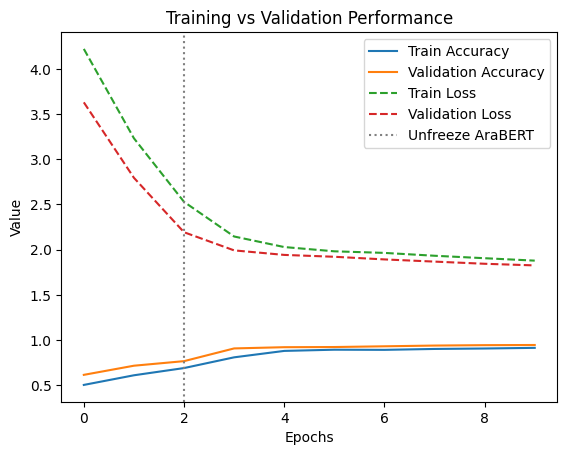

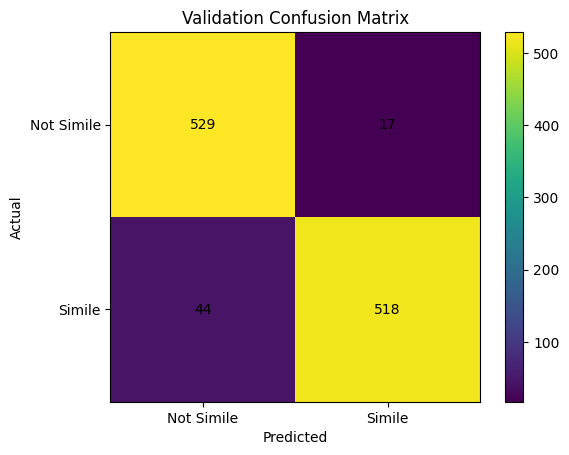

In [85]:
plt.figure()
 
plt.plot(history_merged['accuracy'],     label='Train Accuracy')
plt.plot(history_merged['val_accuracy'], label='Validation Accuracy')
plt.plot(history_merged['loss'],     linestyle='--', label='Train Loss')
plt.plot(history_merged['val_loss'], linestyle='--', label='Validation Loss')
 
# Mark the boundary between phase 1 and phase 2
phase1_epochs = len(history_p1.history['loss'])
plt.axvline(x=phase1_epochs - 1, color='gray',
            linestyle=':', label='Unfreeze AraBERT')
 
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Training vs Validation Performance")
plt.legend()
plt.show()


cm = confusion_matrix(y_val, y_val_pred)
 
plt.figure()
plt.imshow(cm)
plt.title("Validation Confusion Matrix")
plt.colorbar()
 
classes    = ["Not Simile", "Simile"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
 
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
 
plt.show()
 

In [86]:
def explain_prediction(sentence):
 
    print("=" * 65)
    print("SENTENCE:", sentence)
 
    symbolic_result = symbolic_detector(sentence)
 
    enc = tokenizer(
        [arabert_prep.preprocess(sentence)],
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )
    ids  = enc['input_ids']
    mask = enc['attention_mask']
 
    single_cls_attn = extract_attention_patterns(
        ids, mask, batch_size=1, cache_path=None
    )
 
    sym_feat    = build_symbolic_matrix([sentence])
    neural_feat = build_neural_attention_features(
        ids, single_cls_attn, discriminative_tokens
    )
    combined = np.hstack([sym_feat, neural_feat])
 
    final_prob, bert_prob = model.predict_both([ids, mask, combined])
 
    final_prob = float(final_prob[0][0])
    bert_prob  = float(bert_prob[0][0])
    prediction = "Simile ✓" if final_prob > 0.5 else "Not Simile ✗"
 
    # [1] Grammar layer
    print("\n[1] SYMBOLIC GRAMMAR LAYER")
    print(f"  has_structure       : {int(sym_feat[0][0])}")
    print(f"  num_structures      : {int(sym_feat[0][1])}")
    print(f"  max_conf            : {round(float(sym_feat[0][2]), 3)}")
    print(f"  avg_conf            : {round(float(sym_feat[0][3]), 3)}")
    print(f"  has_strong_particle : {int(sym_feat[0][4])}  (كأن / كأنّ)")
    print(f"  has_weak_particle   : {int(sym_feat[0][5])}  (كـ / مثل)")
    print(f"  has_verb            : {int(sym_feat[0][6])}  (يشبه / يماثل)")
    print(f"  has_noun            : {int(sym_feat[0][7])}  (شبيه / مثيل)")
    print(f"  has_prefix          : {int(sym_feat[0][8])}  (كـ prefix)")
    print(f"  avg_distance        : {round(float(sym_feat[0][9]), 3)}")
    print(f"  multi_simile_flag   : {int(sym_feat[0][10])}")
 
    if symbolic_result.structures:
        for s in symbolic_result.structures:
            print(f"\n  Rule: {s.rule}")
            print(f"  المشبه: {s.subject}  |  الأداة: {s.particle}  |  المشبه به: {s.object}")
            print(f"  Confidence: {round(s.confidence, 3)}")
    else:
        print("\n  No grammar structures detected")
 
    # [2] Neural attention layer
    print("\n[2] NEURAL ATTENTION LAYER")
    attn_to_key = float(neural_feat[0][0])
    entropy     = float(neural_feat[0][1])
    pos_bias    = float(neural_feat[0][2])
 
    print(f"  attn_to_key_tokens : {round(attn_to_key, 4)}")
    print(f"  attention_entropy  : {round(entropy, 4)}")
    print(f"  attention_pos_bias : {round(pos_bias, 4)}")
 
    attn_row  = single_cls_attn[0]
    top_5_pos = np.argsort(attn_row)[-5:][::-1]
 
    print("\n  Top tokens AraBERT attended to:")
    for pos in top_5_pos:
        token_str = tokenizer.decode(
            [int(ids[0, pos].numpy())]
        ).strip()
        tag = "← neural rule" if token_str in discriminative_tokens else ""
        print(f"    '{token_str}'  attn={attn_row[pos]:.4f}  {tag}")
 
    print("\n  Symbolic interpretation of AraBERT:")
    print("  →", "Focused on simile indicators (reliable)"
          if attn_to_key > 0.1
          else "Did not focus on known simile indicators")
    print("  →", "Attention focused — confident"
          if entropy < 4.0
          else ("Attention moderate — uncertain"
                if entropy < 4.5
                else "Attention scattered — very uncertain"))
    print("  →", "Early-token focus (normal for Arabic similes)"
          if pos_bias > 0.01
          else "Late-token focus (unusual)")
 
    # [3] Hybrid decision
    print("\n[3] HYBRID DECISION")
    print(f"  AraBERT probability : {round(bert_prob, 3)}")
    print(f"  Final hybrid score  : {round(final_prob, 3)}")
    print(f"  Prediction          : {prediction}")
    print("=" * 65)

In [100]:
explain_prediction("الولد يشبه الشمس في إشراقته")

SENTENCE: الولد يشبه الشمس في إشراقته
  1/1  (100%)

[1] SYMBOLIC GRAMMAR LAYER
  has_structure       : 1
  num_structures      : 1
  max_conf            : 0.927
  avg_conf            : 0.927
  has_strong_particle : 0  (كأن / كأنّ)
  has_weak_particle   : 0  (كـ / مثل)
  has_verb            : 1  (يشبه / يماثل)
  has_noun            : 0  (شبيه / مثيل)
  has_prefix          : 0  (كـ prefix)
  avg_distance        : 2.0
  multi_simile_flag   : 0

  Rule: verb_simile
  المشبه: الولد  |  الأداة: يشبه  |  المشبه به: الشمس
  Confidence: 0.927

[2] NEURAL ATTENTION LAYER
  attn_to_key_tokens : 0.0199
  attention_entropy  : 1.3556
  attention_pos_bias : 0.0625

  Top tokens AraBERT attended to:
    '[CLS]'  attn=0.5457  
    '[SEP]'  attn=0.2369  
    'في'  attn=0.1028  
    'إش'  attn=0.0242  
    'الولد'  attn=0.0230  

  Symbolic interpretation of AraBERT:
  → Did not focus on known simile indicators
  → Attention focused — confident
  → Early-token focus (normal for Arabic similes)

[3] HYBR

In [101]:
explain_prediction("الشمس مشرقة اليوم")

SENTENCE: الشمس مشرقة اليوم
  1/1  (100%)

[1] SYMBOLIC GRAMMAR LAYER
  has_structure       : 0
  num_structures      : 0
  max_conf            : 0.0
  avg_conf            : 0.0
  has_strong_particle : 0  (كأن / كأنّ)
  has_weak_particle   : 0  (كـ / مثل)
  has_verb            : 0  (يشبه / يماثل)
  has_noun            : 0  (شبيه / مثيل)
  has_prefix          : 0  (كـ prefix)
  avg_distance        : 0.0
  multi_simile_flag   : 0

  No grammar structures detected

[2] NEURAL ATTENTION LAYER
  attn_to_key_tokens : 0.0
  attention_entropy  : 0.9776
  attention_pos_bias : 0.0625

  Top tokens AraBERT attended to:
    '[CLS]'  attn=0.6074  
    '[SEP]'  attn=0.3029  
    'اليوم'  attn=0.0362  
    'الشمس'  attn=0.0309  
    'مشرقة'  attn=0.0225  

  Symbolic interpretation of AraBERT:
  → Did not focus on known simile indicators
  → Attention focused — confident
  → Early-token focus (normal for Arabic similes)

[3] HYBRID DECISION
  AraBERT probability : 0.019
  Final hybrid score  : 0.134


In [99]:
# Re-save with explicit signature so the API can load it cleanly
@tf.function(input_signature=[
    tf.TensorSpec(shape=(None, MAX_LEN), dtype=tf.int32, name="input_ids"),
    tf.TensorSpec(shape=(None, MAX_LEN), dtype=tf.int32, name="attention_mask"),
    tf.TensorSpec(shape=(None, 14),      dtype=tf.float32, name="combined_features"),
])
def serving_fn(input_ids, attention_mask, combined_features):
    return model([input_ids, attention_mask, combined_features], training=False)

tf.saved_model.save(
    model,
    "saved_model/",
    signatures={"serving_default": serving_fn}
)
print("Model re-saved with explicit signature.")

Model re-saved with explicit signature.


In [98]:
# 1. Save the trained model
model.save("saved_model/")

with open("discriminative_tokens.json", "w") as f:
    json.dump(
        {k: float(v) for k, v in discriminative_tokens.items()},
        f,
        ensure_ascii=False
    )

print("Done — model and tokens saved.")
# 2. Save discriminative tokens
import json

with open("discriminative_tokens.json", "w") as f:
    json.dump(
        {k: float(v) for k, v in discriminative_tokens.items()},
        f,
        ensure_ascii=False
    )

print("Saved", len(discriminative_tokens), "tokens")

Done — model and tokens saved.
Saved 991 tokens
